In [1]:
# Data
#  ↓
# Plot
#  ↓
# Check stationarity
#  ↓
# Determine d
#  ↓
# Check ACF/PACF
#  ↓
# Choose p and q
#  ↓
# Check seasonality
#  ↓
# Choose s
#  ↓
# Choose P, D, Q
#  ↓
# Fit SARIMA
#  ↓
# Check residuals
#  ↓
# Forecast

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf

In [3]:
data = yf.download("AAPL", start="2024-01-01")

[*********************100%***********************]  1 of 1 completed


In [4]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-01-02,183.404007,186.170285,181.675085,184.895814,82488700
2024-01-03,182.030746,183.641118,181.220616,182.001109,58414500
2024-01-04,179.718964,180.884744,178.701371,179.956063,71983600
2024-01-05,178.997726,180.558698,177.999897,179.797983,62379700
2024-01-08,183.324951,183.364478,179.313856,179.896746,59144500


In [5]:
df=data.iloc[:,:-1]

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 654 entries, 2024-01-02 to 2026-08-11
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, AAPL)  654 non-null    float64
 1   (High, AAPL)   654 non-null    float64
 2   (Low, AAPL)    654 non-null    float64
 3   (Open, AAPL)   654 non-null    float64
dtypes: float64(4)
memory usage: 25.5 KB


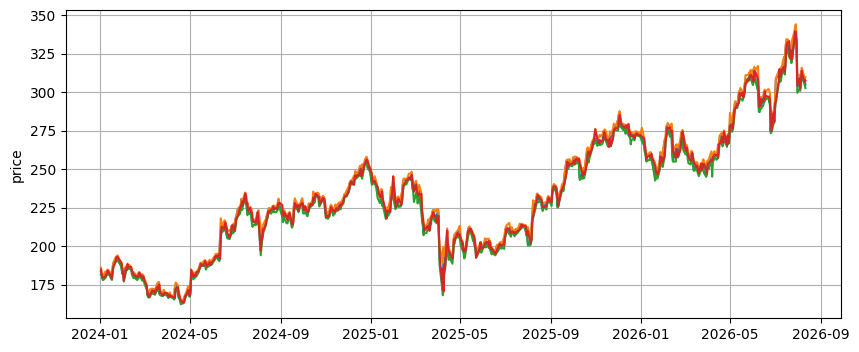

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.plot(df,data=df)
plt.ylabel('price')
plt.grid(True)
plt.show()

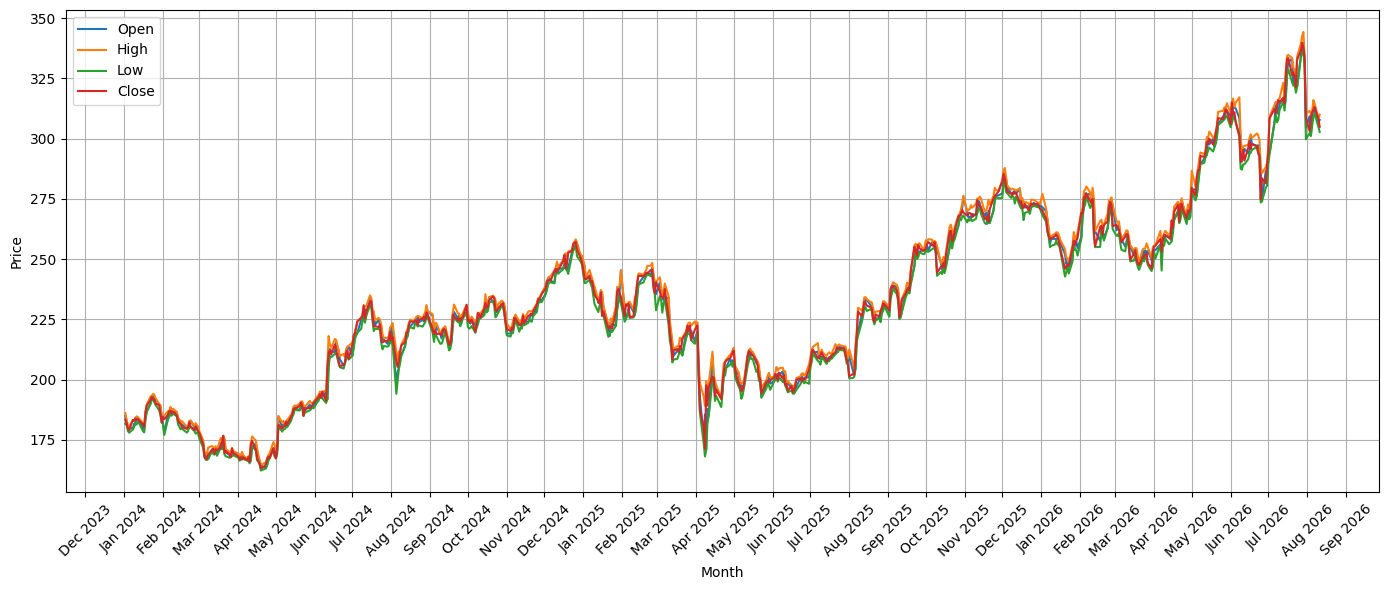

In [11]:
import matplotlib.dates as mdates
plt.figure(figsize=(14, 6))

for col in ['Open', 'High', 'Low', 'Close']:
    plt.plot(df.index, df[col], label=col)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xlabel('Month')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose

<Figure size 1600x900 with 0 Axes>

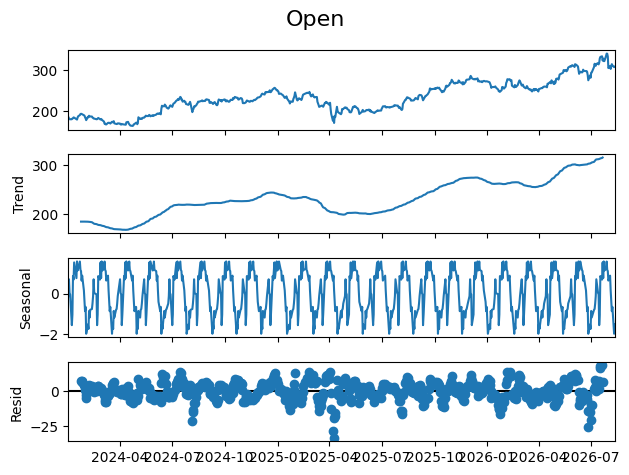

<Figure size 1600x900 with 0 Axes>

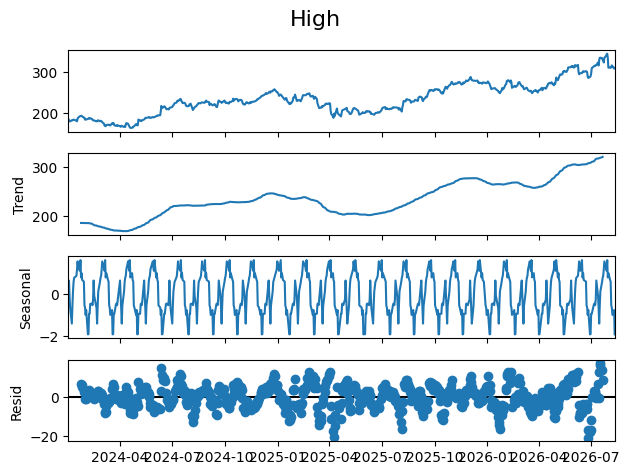

<Figure size 1600x900 with 0 Axes>

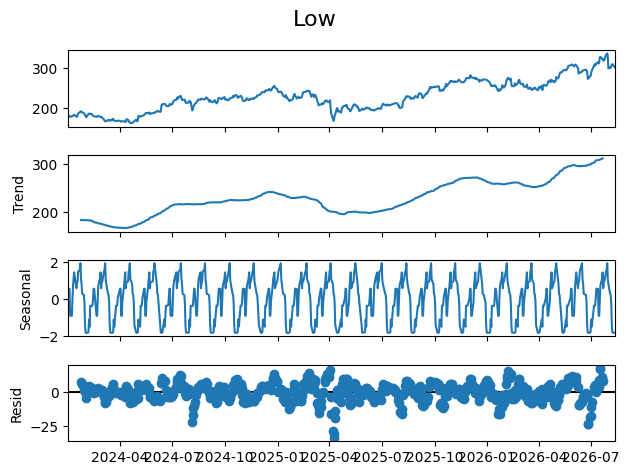

<Figure size 1600x900 with 0 Axes>

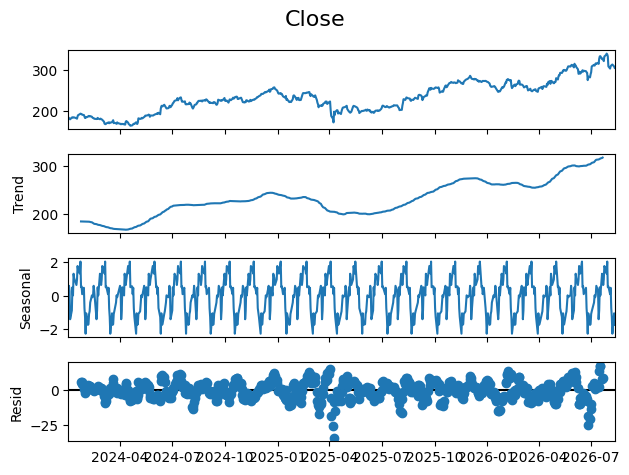

In [24]:
# plt.figure(figsize=(14,5))
import matplotlib.dates as mdates

for col in ['Open', 'High', 'Low', 'Close']:

    result = seasonal_decompose(
        data[col],
        model='additive',
        period=30
    )

    fig = plt.figure(figsize=(16, 9))

    result.plot()

    plt.suptitle(col, fontsize=16)

    plt.tight_layout()

    plt.show()

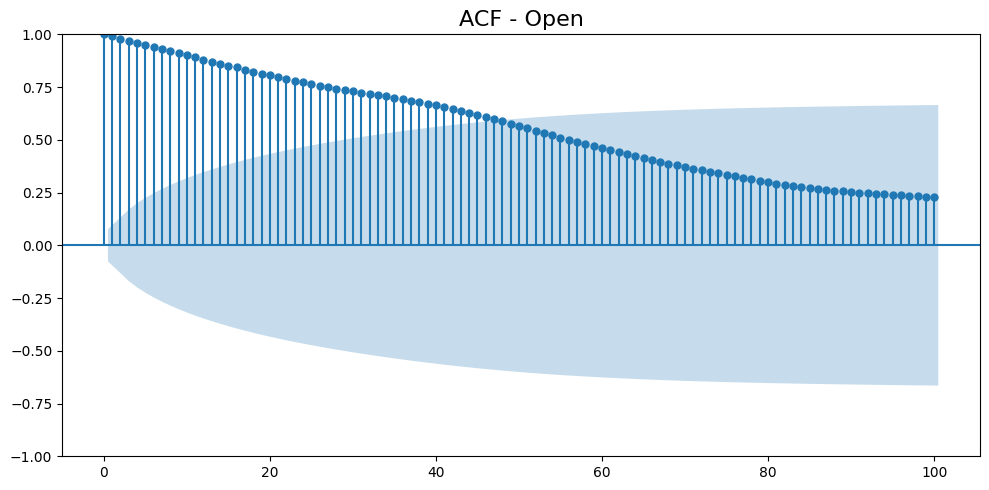

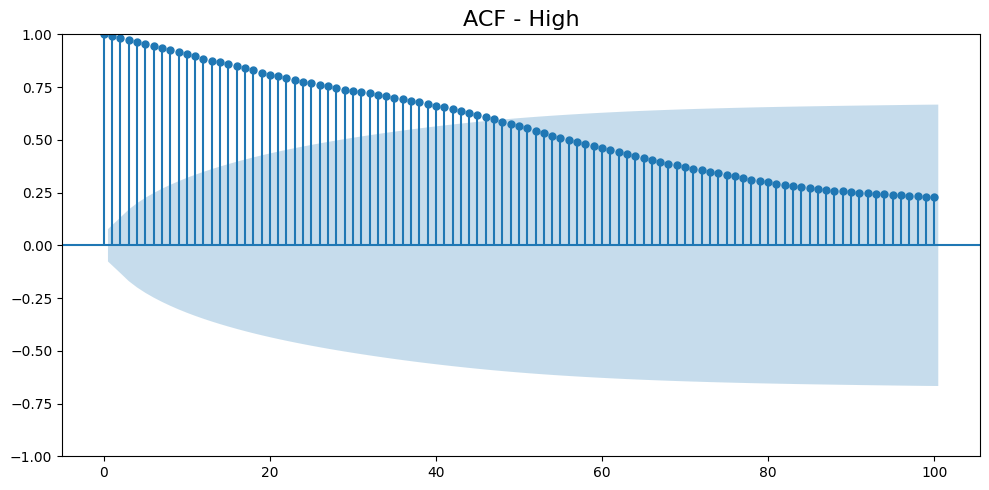

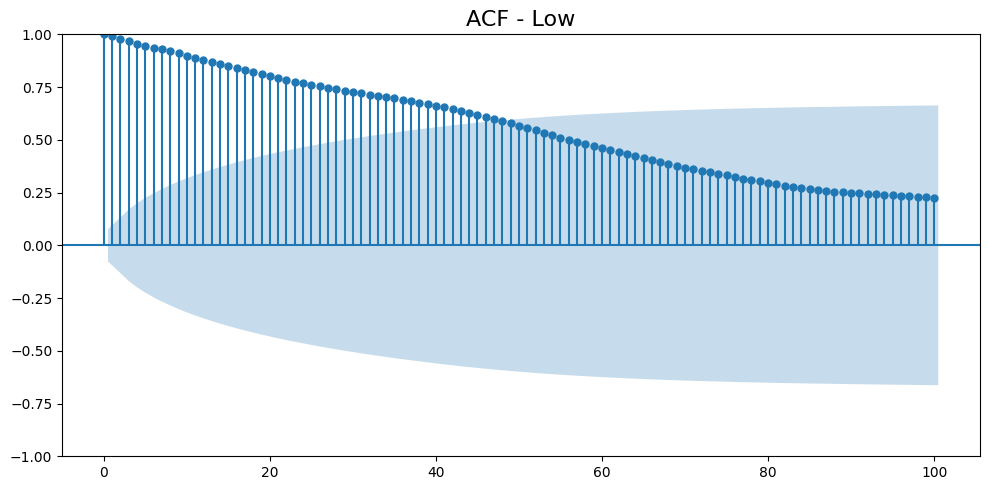

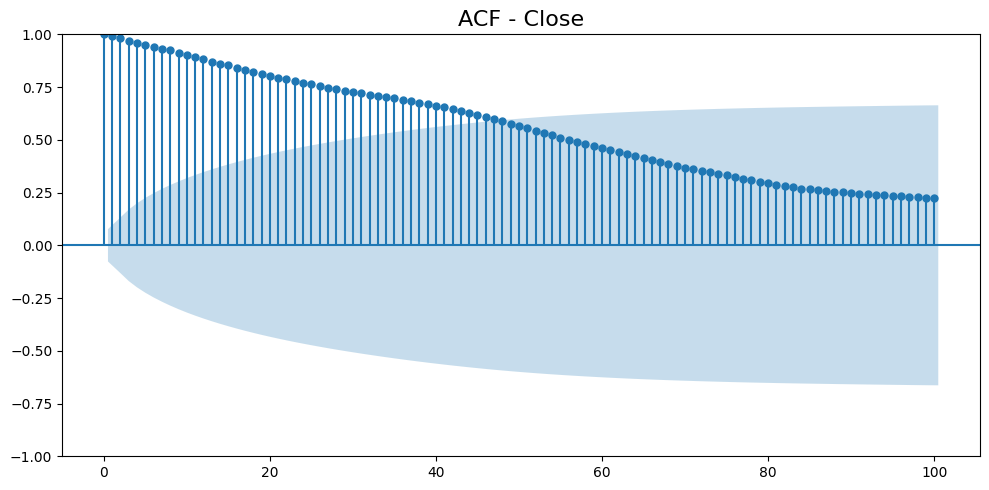

In [28]:
from statsmodels.graphics.tsaplots import plot_acf
for col in ['Open', 'High', 'Low', 'Close']:
    fig, ax = plt.subplots(figsize=(10, 5))
    plot_acf(df[col].dropna(), lags=100, ax=ax)
    ax.set_title(f'ACF - {col}', fontsize=16)
    plt.tight_layout()
    plt.show()

In [29]:
from statsmodels.tsa.stattools import adfuller,kpss
def adf_test(series):
    adf_test=adfuller(series)
    print(f"adf stats:{round(adf_test[0],3)}")
    print(f"p-value stats:{round(adf_test[1],3)}")
    print(f"lags values:{round(adf_test[2],3)}")
    for key,value in adf_test[4].items():
     print(f"{key}:{round(value,3)}")
        
def kpss_test(series):
    kpss_test=kpss(series,regression='ct')
    print("KPSS Statistic:", kpss_test[0])
    print("p-value:", kpss_test[1])
    print("Lags used:", kpss_test[2])
    print("Critical values:", kpss_test[3].items())

In [35]:

    adf_test(df['Close'])
    kpss_test(df['Close'])

adf stats:-0.856
p-value stats:0.802
lags values:5
1%:-3.44
5%:-2.866
10%:-2.569
KPSS Statistic: 0.3088468905721899
p-value: 0.01
Lags used: 16
Critical values: dict_items([('10%', 0.119), ('5%', 0.146), ('2.5%', 0.176), ('1%', 0.216)])


C:\Users\Mcc\AppData\Local\Temp\ipykernel_25052\594276763.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test=kpss(series,regression='ct')


In [36]:
df_diff=df['Close'].diff().dropna()

In [37]:
    adf_test(df_diff)
    kpss_test(df_diff)

adf stats:-12.871
p-value stats:0.0
lags values:4
1%:-3.44
5%:-2.866
10%:-2.569
KPSS Statistic: 0.03647375623470958
p-value: 0.1
Lags used: 6
Critical values: dict_items([('10%', 0.119), ('5%', 0.146), ('2.5%', 0.176), ('1%', 0.216)])


C:\Users\Mcc\AppData\Local\Temp\ipykernel_25052\594276763.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test=kpss(series,regression='ct')


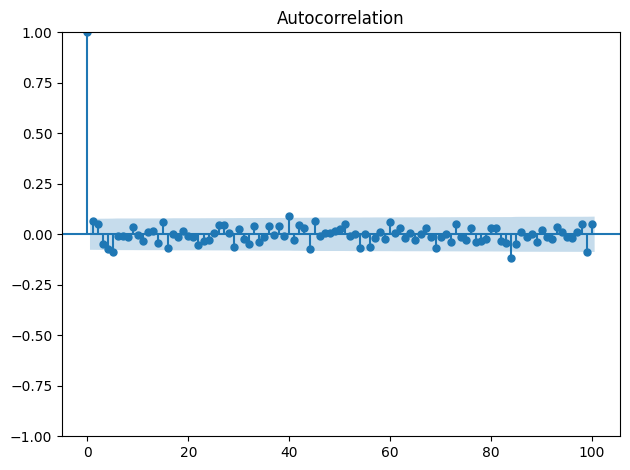

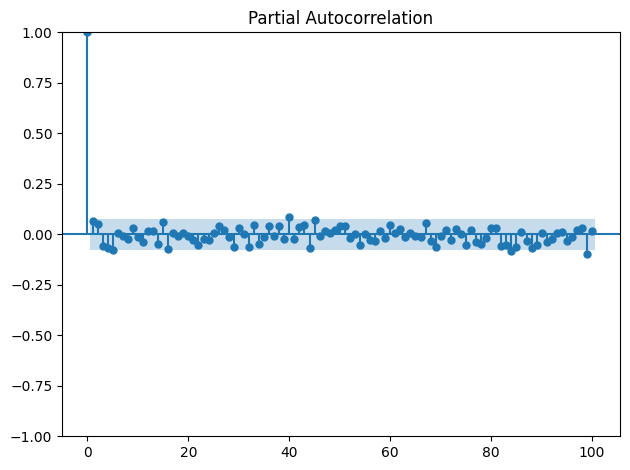

In [42]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
plot_acf(df_diff.dropna(), lags=100)
plt.tight_layout()
plt.show()

plot_pacf(df_diff.dropna(),lags=100)
plt.tight_layout()
plt.show()

In [43]:
from statsmodels.tsa.stattools import acf

close_diff = df['Close'].diff().dropna()

acf_values = acf(close_diff, nlags=100)

for lag in [5, 10, 15, 20, 21, 30, 40, 60]:
    print(lag, round(acf_values[lag], 4))

5 -0.0888
10 -0.005
15 0.0595
20 -0.0098
21 -0.0144
30 0.0239
40 0.093
60 0.06


In [56]:
df.info()
train=close_diff.iloc[:600]
test=close_diff.iloc[600:]


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 654 entries, 2024-01-02 to 2026-08-11
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, AAPL)  654 non-null    float64
 1   (High, AAPL)   654 non-null    float64
 2   (Low, AAPL)    654 non-null    float64
 3   (Open, AAPL)   654 non-null    float64
dtypes: float64(4)
memory usage: 25.5 KB


In [58]:
train.head()

Ticker,AAPL
Date,
2024-01-03,-1.373260
2024-01-04,-2.311783
2024-01-05,-0.721237
2024-01-08,4.327225
2024-01-09,-0.414917


In [65]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(0, 0, 0, 0)
)

results = model.fit()

print(results.summary())

C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                   AAPL   No. Observations:                  600
Model:               SARIMAX(1, 1, 1)   Log Likelihood               -1637.128
Date:                Wed, 12 Aug 2026   AIC                           3280.255
Time:                        18:37:45   BIC                           3293.441
Sample:                             0   HQIC                          3285.389
                                - 600                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0586      0.027      2.147      0.032       0.005       0.112
ma.L1         -0.9995      0.062    -16.236      0.000      -1.120      -0.879
sigma2        13.7122      0.983     13.944      0.0

In [66]:
forecast = results.forecast(steps=len(test))

C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


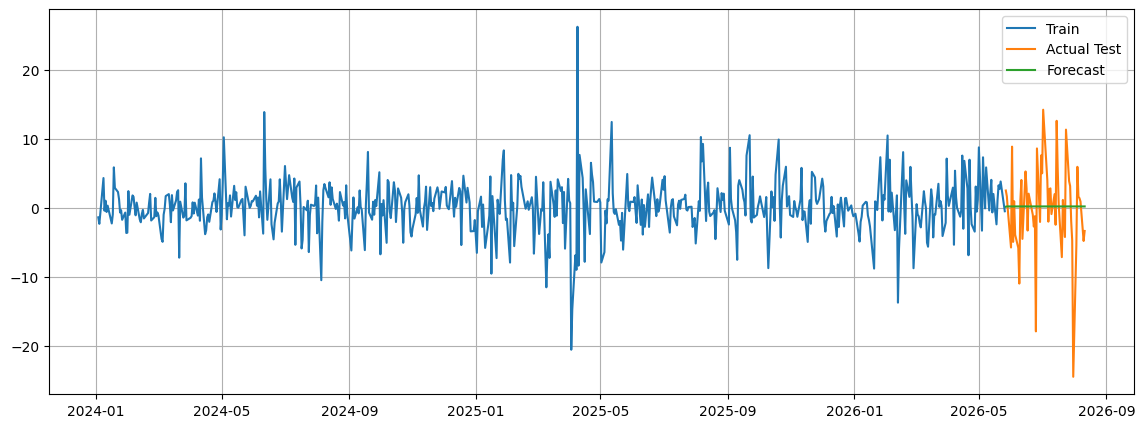

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual Test')
plt.plot(test.index, forecast, label='Forecast')

plt.legend()
plt.grid(True)
plt.show()

In [68]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, forecast)

rmse = np.sqrt(
    mean_squared_error(test, forecast)
)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 4.751970283606964
RMSE: 6.590042028327939


In [50]:
# SARIMA(1,1,1)(1,0,1,5)
# SARIMA(1,1,1)(1,0,1,20)
# SARIMA(1,1,1)(1,0,1,30)

In [90]:
model = SARIMAX(
    train,
    order=(4, 1, 4),
    seasonal_order=(2, 0, 2, 10)
)
results = model.fit()
print(results.summary())

C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                        SARIMAX Results                                        
Dep. Variable:                                    AAPL   No. Observations:                  600
Model:             SARIMAX(4, 1, 4)x(2, 0, [1, 2], 10)   Log Likelihood               -1630.619
Date:                                 Wed, 12 Aug 2026   AIC                           3287.237
Time:                                         18:44:53   BIC                           3344.376
Sample:                                              0   HQIC                          3309.482
                                                 - 600                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.4415      0.466     -3.091      0.002      -2.355      -0

In [88]:
forecast = results.forecast(steps=len(test))

C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [89]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, forecast)

rmse = np.sqrt(
    mean_squared_error(test, forecast)
)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 4.721507410223834
RMSE: 6.583544454962395


In [91]:
from pmdarima import auto_arima

In [92]:
model = auto_arima(
    train,
    seasonal=False,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=3280.879, Time=0.61 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=3278.255, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=3278.098, Time=0.05 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=3278.303, Time=0.08 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=3278.649, Time=0.08 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=3279.575, Time=0.18 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=3280.351, Time=0.29 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=3278.425, Time=0.14 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0]          
Total fit time: 1.488 seconds


In [94]:
import pmdarima as pm

In [95]:
model = pm.auto_arima(
    train,
    seasonal=True,
    m=5,
    start_p=0,
    start_q=0,
    max_p=3,
    max_q=3,
    start_P=0,
    start_Q=0,
    max_P=2,
    max_Q=2,
    d=None,
    D=None,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[5] intercept   : AIC=3278.372, Time=0.07 sec
 ARIMA(1,0,0)(1,0,0)[5] intercept   : AIC=3279.564, Time=0.38 sec
 ARIMA(0,0,1)(0,0,1)[5] intercept   : AIC=3279.682, Time=0.34 sec
 ARIMA(0,0,0)(0,0,0)[5]             : AIC=3278.255, Time=0.05 sec
 ARIMA(0,0,0)(1,0,0)[5] intercept   : AIC=3279.323, Time=0.13 sec
 ARIMA(0,0,0)(0,0,1)[5] intercept   : AIC=3279.287, Time=0.16 sec
 ARIMA(0,0,0)(1,0,1)[5] intercept   : AIC=3281.263, Time=0.83 sec
 ARIMA(1,0,0)(0,0,0)[5] intercept   : AIC=3278.425, Time=0.17 sec
 ARIMA(0,0,1)(0,0,0)[5] intercept   : AIC=3278.601, Time=0.14 sec
 ARIMA(1,0,1)(0,0,0)[5] intercept   : AIC=3279.985, Time=0.34 sec

Best model:  ARIMA(0,0,0)(0,0,0)[5]          
Total fit time: 2.640 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  600
Model:                        SARIMAX   Log Likelihood        